In [6]:
import pandas as pd
import numpy as np
import glob
from tqdm.auto import tqdm

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import transforms
import pathlib
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torch.optim.lr_scheduler import ExponentialLR
from torchviz import make_dot

import pytorch_lightning as pl

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib
from matplotlib.ticker import MaxNLocator

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics.functional import accuracy

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

import datetime
import time
import random
import os


# setting device on GPU if available, else CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda:0

NVIDIA RTX A6000
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [7]:
class StdConvPWBlock(nn.Module):
    """
    Standard 3x3 convolution + pointwise 1x1 convolution block.
    """
    def __init__(self, inp, oup, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                inp, oup,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(oup),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                oup, oup,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(oup),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class LCNN_ProposedProgression(nn.Module):
    """
    L-CNN (proposed progression)

    Table description:
    - Mixing: StdConv (3x3) + PW
    - Channel progression: 8 -> 16 -> 32 -> 64
    - 4 stages (s=2)
    - GAP + Linear
    """
    def __init__(self, num_classes=10, in_channels=1):
        super().__init__()

        self.stage1 = StdConvPWBlock(in_channels, 8, stride=2)   # 1 -> 8
        self.stage2 = StdConvPWBlock(8, 16, stride=2)            # 8 -> 16
        self.stage3 = StdConvPWBlock(16, 32, stride=2)           # 16 -> 32
        self.stage4 = StdConvPWBlock(32, 64, stride=2)           # 32 -> 64

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [8]:
def load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42,
    drop_last_train=True
):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"NPZ not found: {os.path.abspath(npz_path)}")

    data = np.load(npz_path)
    required = {"X_train", "y_train", "X_test", "y_test"}
    if not required.issubset(set(data.files)):
        raise KeyError(f"NPZ must contain {sorted(required)}. Found: {data.files}")

    # Train tensors
    X_train = torch.from_numpy(data["X_train"]).float()
    y_train = torch.from_numpy(data["y_train"]).long()
    train_dataset = TensorDataset(X_train, y_train)

    # Test tensors
    X_test = torch.from_numpy(data["X_test"]).float()
    y_test = torch.from_numpy(data["y_test"]).long()
    test_dataset = TensorDataset(X_test, y_test)

    # Deterministic shuffle for train
    generator = None
    if shuffle_train:
        generator = torch.Generator()
        generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        generator=generator,
        drop_last=drop_last_train
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, test_loader

In [9]:
# usage
npz_path = "Prepared/Kia_human_train_test_chunks.npz"
train_loader, test_loader = load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42
)

# sanity check
x_tr, y_tr = next(iter(train_loader))
x_te, y_te = next(iter(test_loader))
print("Train batch:", x_tr.shape, y_tr.shape)
print("Test  batch:", x_te.shape, y_te.shape)
print("Train labels unique (batch):", torch.unique(y_tr))
print("Test  labels unique (batch):", torch.unique(y_te))

Train batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Test  batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Train labels unique (batch): tensor([0, 1, 2, 3, 6, 7])
Test  labels unique (batch): tensor([ 0,  1,  2,  3,  7, 10])


In [10]:
model = LCNN_ProposedProgression(num_classes=11)

# Define the loss function (e.g., cross-entropy loss)
criterion = nn.CrossEntropyLoss()

# Choose an optimizer (e.g., Adam optimizer)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

# Set the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LCNN_ProposedProgression(
  (stage1): StdConvPWBlock(
    (block): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (stage2): StdConvPWBlock(
    (block): Sequential(
      (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (stage3): StdConvPWBlock(
    (block): Sequen

In [11]:
# Initialize variables for early stopping
best_val_loss = np.Inf
patience = 3  # Number of epochs to wait for improvement
counter = 0  # Counter for epochs without improvement
num_epochs = 150

# Move model to device
model.to(device)

train_dataset_len = len(train_loader.dataset)
test_dataset_len = len(test_loader.dataset)

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    
    # Training loop
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()  # Zero the parameter gradients
        
        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Optimize
        
        running_loss += loss.item() * inputs.size(0)  # Accumulate loss
    
    # Calculate average training loss for the epoch
    epoch_train_loss = running_loss / train_dataset_len
    
    # Validation loop
    model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for val_inputs, val_labels in test_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
            _, predicted = torch.max(val_outputs, 1)
            total += val_labels.size(0)
            correct += (predicted == val_labels).sum().item()
    
    # Calculate average validation loss and accuracy for the epoch
    epoch_val_loss = running_val_loss / test_dataset_len
    val_accuracy = correct / total
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.2%}")
    
    # Check for early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0  # Reset counter if validation loss improves
        # Save the model
        torch.save(model.state_dict(), "models/Kia_K_MobileNetV1_Lite_Only_PWAndStdConvProProg_20_Over_50.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

Epoch [1/150], Train Loss: 0.4786, Val Loss: 0.3334, Val Accuracy: 87.44%
Epoch [2/150], Train Loss: 0.3038, Val Loss: 0.2415, Val Accuracy: 90.01%
Epoch [3/150], Train Loss: 0.2144, Val Loss: 0.1766, Val Accuracy: 92.50%
Epoch [4/150], Train Loss: 0.1501, Val Loss: 0.1886, Val Accuracy: 91.93%
Epoch [5/150], Train Loss: 0.1226, Val Loss: 0.0945, Val Accuracy: 95.86%
Epoch [6/150], Train Loss: 0.1047, Val Loss: 0.0828, Val Accuracy: 96.66%
Epoch [7/150], Train Loss: 0.0898, Val Loss: 0.0793, Val Accuracy: 96.94%
Epoch [8/150], Train Loss: 0.0793, Val Loss: 0.0890, Val Accuracy: 96.42%
Epoch [9/150], Train Loss: 0.0725, Val Loss: 0.0612, Val Accuracy: 97.67%
Epoch [10/150], Train Loss: 0.0660, Val Loss: 0.0632, Val Accuracy: 97.73%
Epoch [11/150], Train Loss: 0.0626, Val Loss: 0.0853, Val Accuracy: 96.58%
Epoch [12/150], Train Loss: 0.0584, Val Loss: 0.0446, Val Accuracy: 98.35%
Epoch [13/150], Train Loss: 0.0561, Val Loss: 0.0386, Val Accuracy: 98.54%
Epoch [14/150], Train Loss: 0.0535

## Test Model

In [12]:
import torch
from sklearn.metrics import confusion_matrix
from src.MobileNetV1LiteOnlyPWAndStdConvProProg import LCNN_ProposedProgression
from src.inference import LoadTestData, GetPrediction, GetProbsAndLabels
from src.metrics import PlotConfusionMatrixKia, ComputeFullMetrics, PlotPRCurve

In [13]:
# ---------- 4) Load model weights ----------
def LoadModel(ckpt_path, device, num_classes=11):
    model = LCNN_ProposedProgression(num_classes=num_classes)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    return model

In [14]:
# ---------- 5) Run prediction ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "models/Kia_K_MobileNetV1_Lite_Only_PWAndStdConvProProg_20_Over_50.pth"
npz_path = "Prepared/Kia_human_train_test_chunks.npz"
test_loader = LoadTestData(npz_path, batch_size=64)
model = LoadModel(ckpt_path, device=device, num_classes=11)

In [15]:
pred = GetPrediction(model, test_loader, device)
y_pred = pred[0]
y_test = pred[1]
cf_matrix = confusion_matrix(y_test, y_pred)

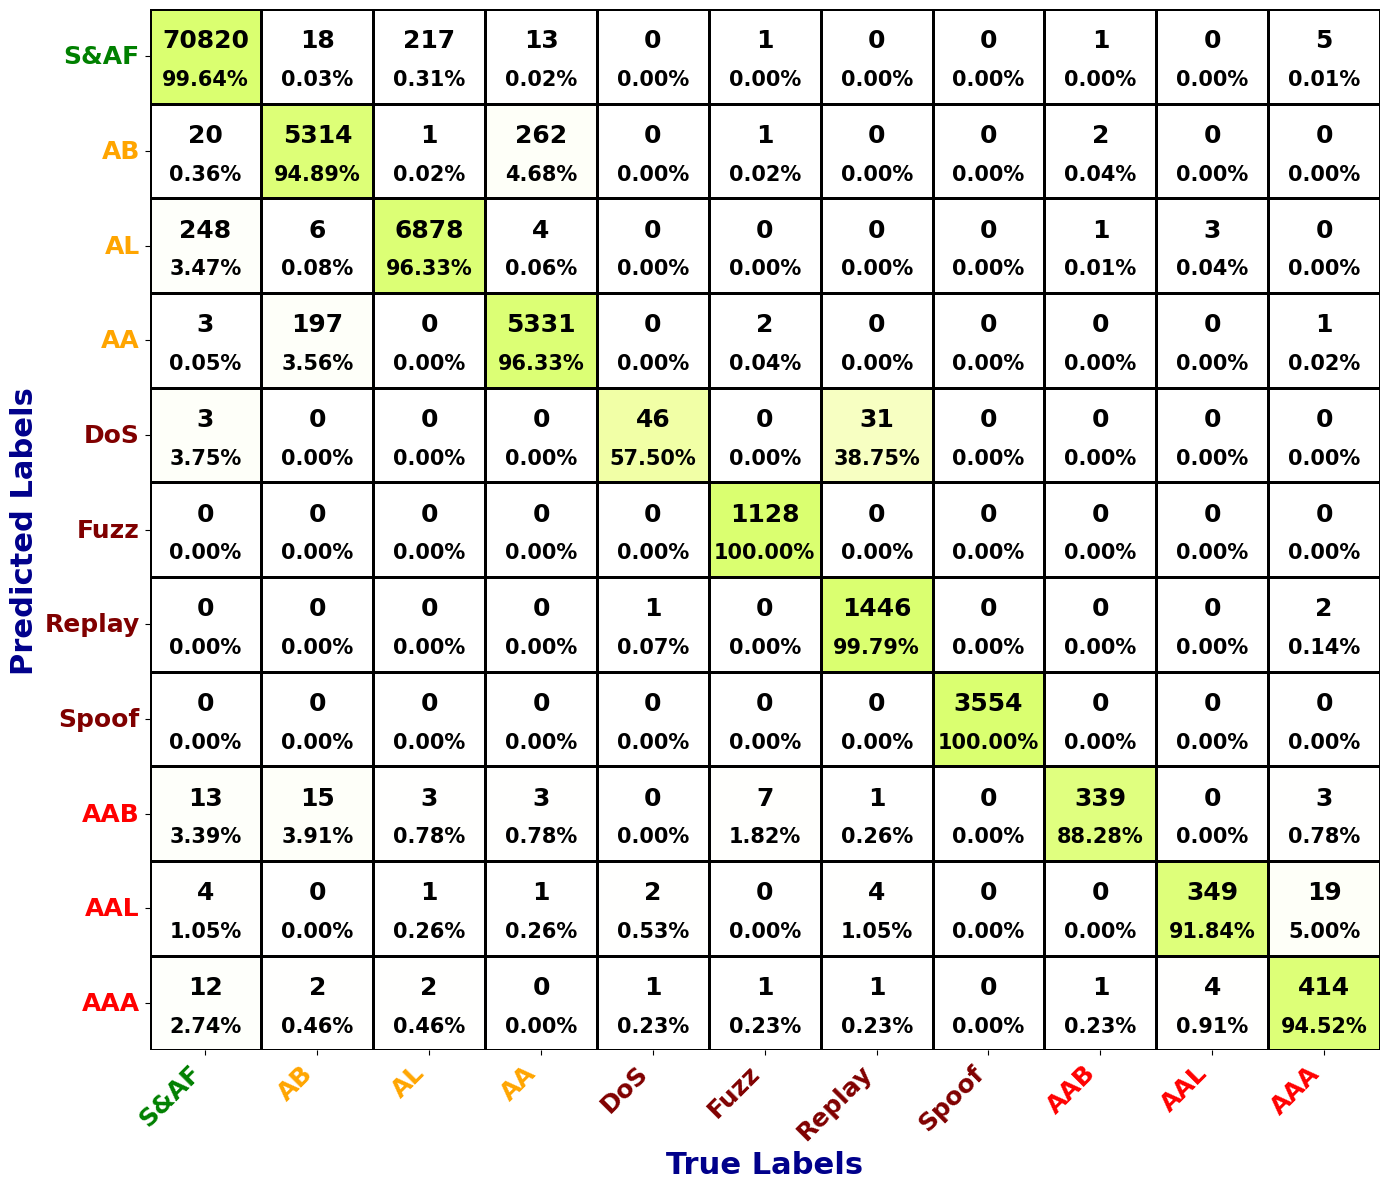

In [16]:
# --- Updated class labels --- #
class_labels = ["S&AF", "AB", "AL", "AA", "DoS", "Fuzz", "Replay", "Spoof", "AAB", "AAL", "AAA"]
PlotConfusionMatrixKia(cf_matrix, class_labels)

In [17]:
stats_df = ComputeFullMetrics(cf_matrix, class_labels)
print(stats_df['F1'].mean())
print("\n")
print(stats_df)

0.9435181818181818


     Class  Support  Precision  Recall      F1  Accuracy  Error_Rate  \
0     S&AF    71075     0.9957  0.9964  0.9961    0.9964      0.0036   
1       AB     5600     0.9571  0.9489  0.9530    0.9489      0.0511   
2       AL     7140     0.9685  0.9633  0.9659    0.9633      0.0367   
3       AA     5534     0.9496  0.9633  0.9564    0.9633      0.0367   
4      DoS       80     0.9200  0.5750  0.7077    0.5750      0.4250   
5     Fuzz     1128     0.9895  1.0000  0.9947    1.0000      0.0000   
6   Replay     1449     0.9751  0.9979  0.9864    0.9979      0.0021   
7    Spoof     3554     1.0000  1.0000  1.0000    1.0000      0.0000   
8      AAB      384     0.9855  0.8828  0.9313    0.8828      0.1172   
9      AAL      380     0.9803  0.9184  0.9484    0.9184      0.0816   
10     AAA      438     0.9324  0.9452  0.9388    0.9452      0.0548   

    CI_Lower  CI_Upper  AUC  
0     0.9959    0.9968  1.0  
1     0.9428    0.9544  1.0  
2     0.9587    0.9674  

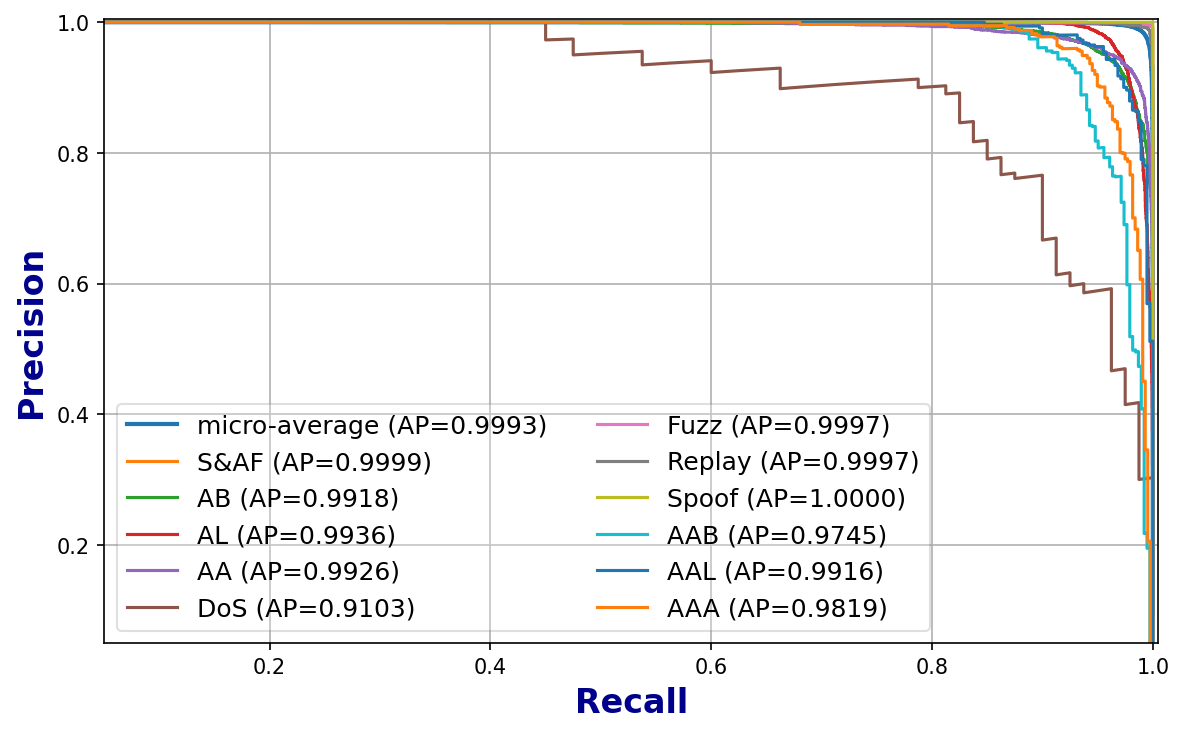

{'AP_micro': 0.9992618224086391,
 'AP_macro': 0.9850565397403573,
 'AP_per_class': {'S&AF': 0.999871059724992,
  'AB': 0.9917819748993086,
  'AL': 0.9935709676156914,
  'AA': 0.992614518224905,
  'DoS': 0.9103353632820153,
  'Fuzz': 0.9996601393067176,
  'Replay': 0.9997123538206456,
  'Spoof': 1.0,
  'AAB': 0.9745056488166184,
  'AAL': 0.9916404861866107,
  'AAA': 0.9819294252664251}}

In [18]:
y_test, y_score = GetProbsAndLabels(model, test_loader, device)
PlotPRCurve(
    y_true=y_test,
    y_score=y_score,
    class_labels=["S&AF","AB","AL","AA","DoS","Fuzz","Replay","Spoof", "AAB","AAL","AAA"],
    xlim=(0.05, 1.005),
    ylim=(0.05, 1.005),
)

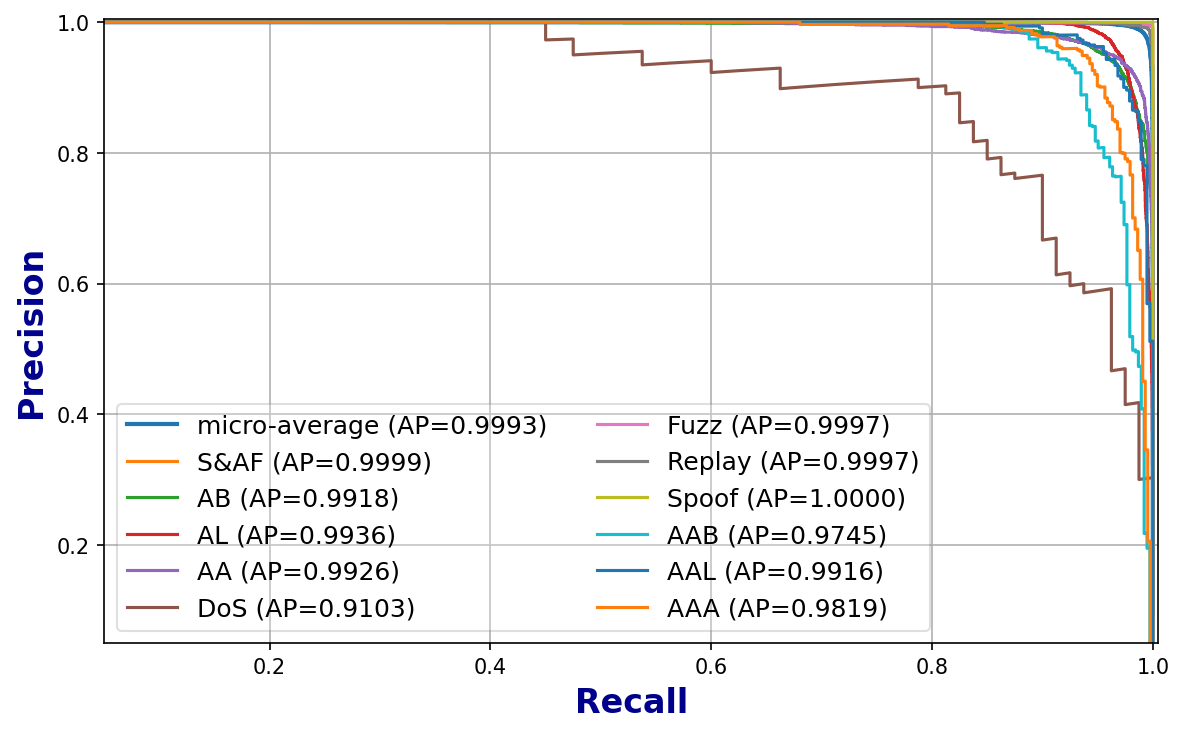

{'AP_micro': 0.9992618224086391,
 'AP_macro': 0.9850565397403573,
 'AP_per_class': {'S&AF': 0.999871059724992,
  'AB': 0.9917819748993086,
  'AL': 0.9935709676156914,
  'AA': 0.992614518224905,
  'DoS': 0.9103353632820153,
  'Fuzz': 0.9996601393067176,
  'Replay': 0.9997123538206456,
  'Spoof': 1.0,
  'AAB': 0.9745056488166184,
  'AAL': 0.9916404861866107,
  'AAA': 0.9819294252664251}}

In [19]:
y_test, y_score = GetProbsAndLabels(model, test_loader, device)
PlotPRCurve(
    y_true=y_test,
    y_score=y_score,
    class_labels=["S&AF","AB","AL","AA","DoS","Fuzz","Replay","Spoof", "AAB","AAL","AAA"],
    xlim=(0.05, 1.005),
    ylim=(0.05, 1.005),
)

In [20]:
def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

params = count_parameters(model, trainable_only=True)
print(f"Trainable params: {params:,}")
print(f"Model size (fp32): {params*4/1024/1024:.2f} MB")

Trainable params: 30,899
Model size (fp32): 0.12 MB


In [21]:
from thop import profile

device = next(model.parameters()).device
model.eval()

# Example input for MobileNetV1Lite
x = torch.randn(1, 1, 20, 10).to(device)   # adjust shape if your real input differs

macs, params_thop = profile(model, inputs=(x,), verbose=False)

# THOP returns MACs; FLOPs are often reported as 2 * MACs
flops = 2 * macs

print(f"THOP params: {params_thop:,}")
print(f"MACs : {macs:,}")
print(f"FLOPs: {flops:,}")
print(f"FLOPs (MFLOPs): {flops/1e6:.6f}")

THOP params: 30,899.0
MACs : 115,344.0
FLOPs: 230,688.0
FLOPs (MFLOPs): 0.230688
